In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL3Nrb2pha3UtYWRtaW4vRG9jdW1lbnRzL3Byb2plY3RzL2FwcGxpZWQtc29mdC1jb21wL2RvY3MvbGVjdHVyZS1ub3RlL20wNy1yZXByZXNlbnRhdGlvbg=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/opt/homebrew/Cellar/python@3.12/3.12.5/Frameworks/Python.framework/Versions/3.12/lib/python3.12/importlib/_bootstrap.py": 1722971329.0, "/opt/homebrew/Cellar/python@3.12/3.12.5/Frameworks/Python.framework/Versions/3.12/lib/python3.12/importlib/_bootstrap_external.py": 1722971329.0, "/opt/homebrew/Cellar/python@3.12/3.12.5/Frameworks/Python.framework/Versions/3.12/lib/python3.12/zipimport.py": 1722971329.0, "/opt/homebrew/Cellar/python@3.12/3.12.5/Frameworks/Python.framework/Versions/3.12/lib/python3.12/codecs.py": 1722971329.0, "/opt/homebrew/Cellar/python@3.12/3.12.5/Frameworks/Python.framework/Versions/3.12/lib/python3.12/encodings/aliases.py": 1722971329.0, "/opt/homebrew/Cellar/python@3.12/3.12.5/Frameworks/Python.framework/Versions/3.12/lib/python3.12/encodings/__init__.py": 1722971329.0, "/opt/homebrew/Cellar/python@3.12/3.12.5/Frameworks/Python.framework/Versions/3.12/lib/python3.12/encodings/utf_8.py": 1722971329.0, "/opt/homebrew/Cellar/python@3.12/3.12.5/Frameworks/Python.

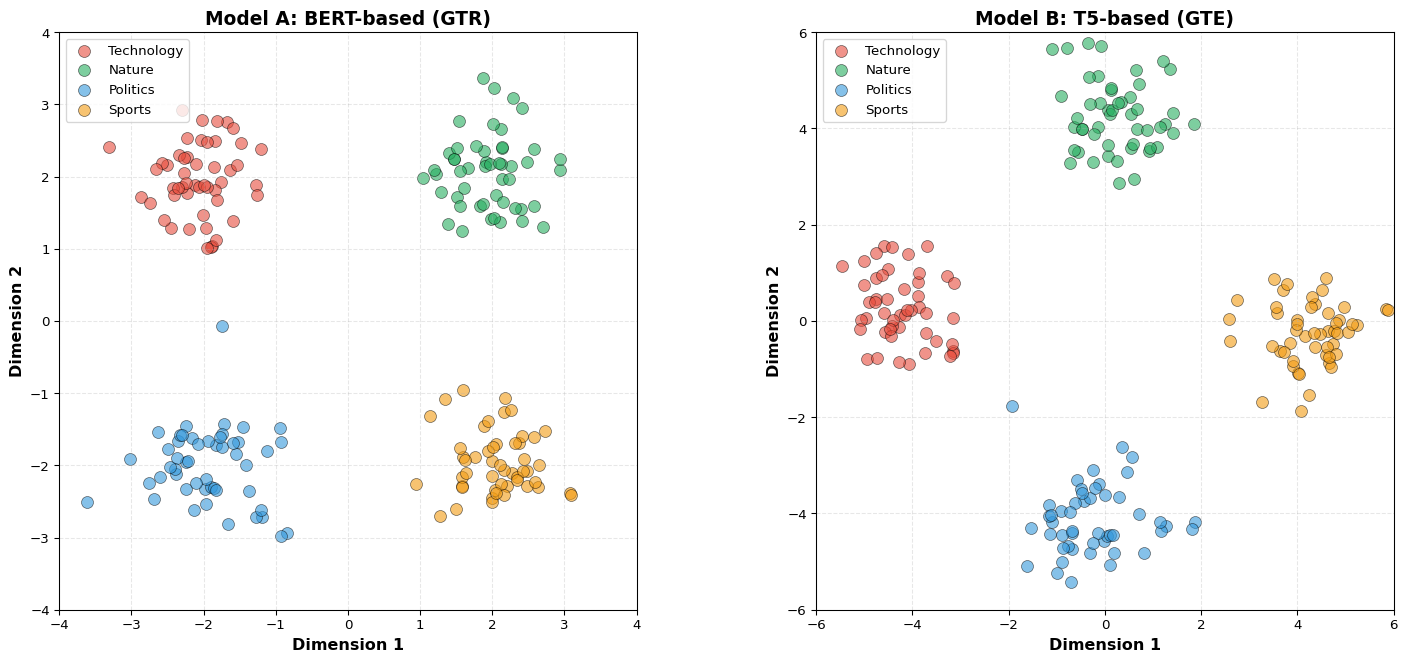

In [2]:
#| fig-cap: Two models trained independently produce fundamentally incomparable embedding spaces.
#| label: fig-incomparable-spaces
#| code-fold: true

import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

np.random.seed(42)

# Model A: BERT-style embeddings
n_points = 50
clusters_A = {
    'Technology': np.random.randn(n_points, 2) * 0.5 + np.array([-2, 2]),
    'Nature': np.random.randn(n_points, 2) * 0.5 + np.array([2, 2]),
    'Politics': np.random.randn(n_points, 2) * 0.5 + np.array([-2, -2]),
    'Sports': np.random.randn(n_points, 2) * 0.5 + np.array([2, -2]),
}

colors = {'Technology': '#e74c3c', 'Nature': '#27ae60',
          'Politics': '#3498db', 'Sports': '#f39c12'}

for topic, points in clusters_A.items():
    ax1.scatter(points[:, 0], points[:, 1], s=80, c=colors[topic],
                alpha=0.6, edgecolors='black', linewidth=0.5, label=topic)

ax1.set_xlim(-4, 4)
ax1.set_ylim(-4, 4)
ax1.set_xlabel('Dimension 1', fontsize=12, fontweight='bold')
ax1.set_ylabel('Dimension 2', fontsize=12, fontweight='bold')
ax1.set_title('Model A: BERT-based (GTR)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_aspect('equal')

# Model B: T5-style embeddings (rotated and scaled differently)
rotation = np.array([[np.cos(0.7), -np.sin(0.7)],
                     [np.sin(0.7), np.cos(0.7)]])
scale = 1.5

clusters_B = {}
for topic, points in clusters_A.items():
    clusters_B[topic] = (points @ rotation.T) * scale

for topic, points in clusters_B.items():
    ax2.scatter(points[:, 0], points[:, 1], s=80, c=colors[topic],
                alpha=0.6, edgecolors='black', linewidth=0.5, label=topic)

ax2.set_xlim(-6, 6)
ax2.set_ylim(-6, 6)
ax2.set_xlabel('Dimension 1', fontsize=12, fontweight='bold')
ax2.set_ylabel('Dimension 2', fontsize=12, fontweight='bold')
ax2.set_title('Model B: T5-based (GTE)', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

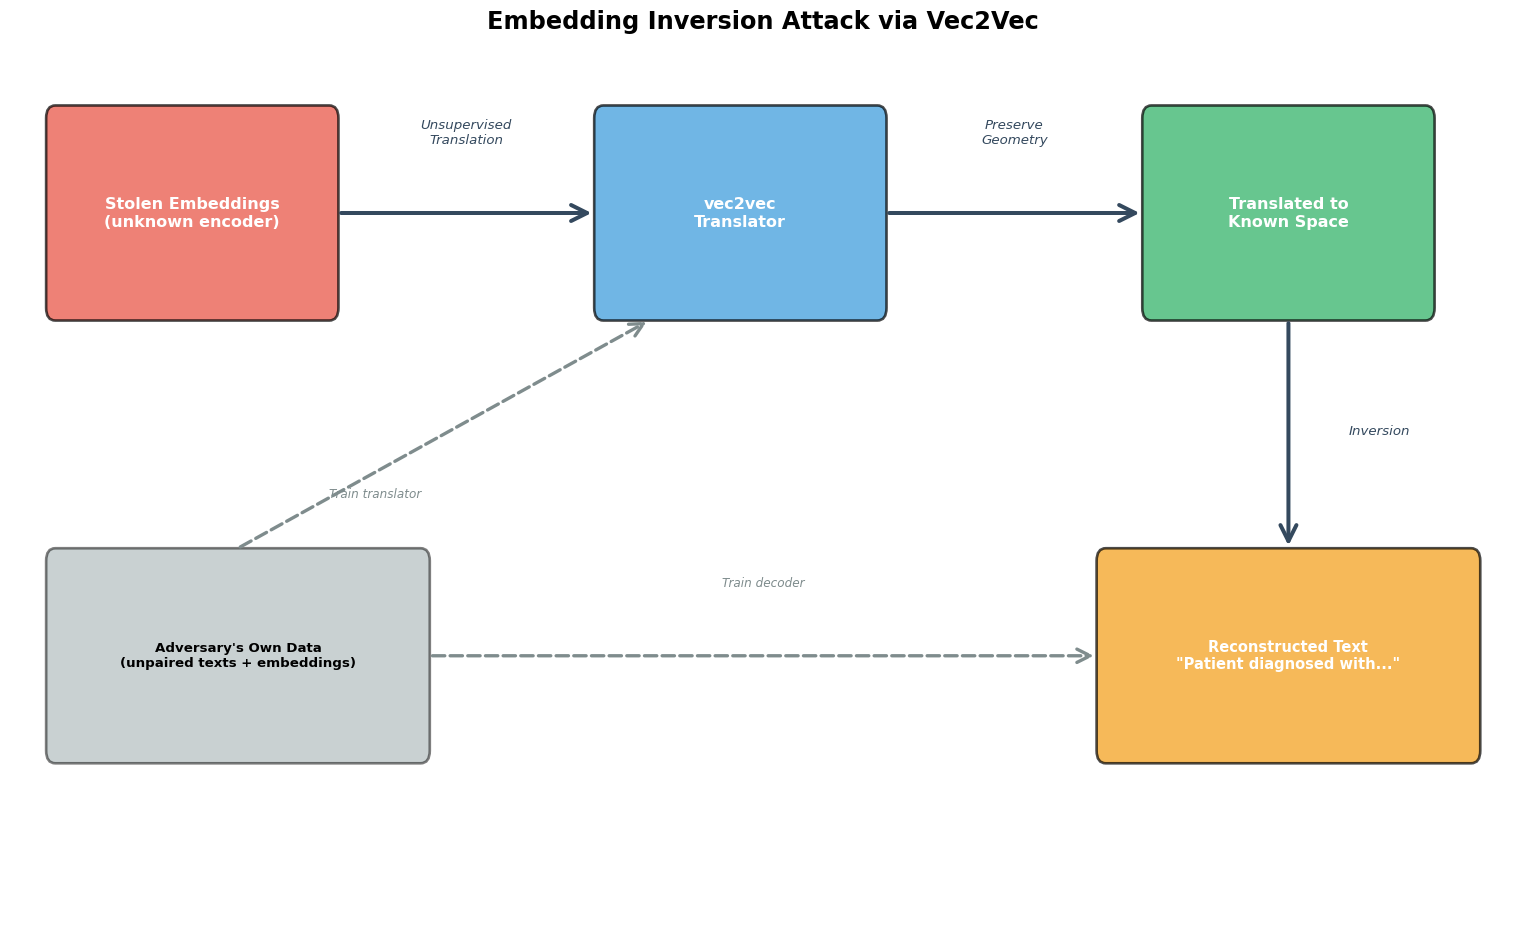

In [3]:
#| fig-cap: Embedding inversion attack pipeline using vec2vec translation.
#| label: fig-inversion-attack
#| code-fold: true

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(16, 10))

# Stage 1: Stolen embeddings
box1 = FancyBboxPatch((0, 7), 3, 1.5, boxstyle="round,pad=0.1",
                      facecolor='#e74c3c', edgecolor='black', linewidth=2, alpha=0.7)
ax.add_patch(box1)
ax.text(1.5, 7.75, 'Stolen Embeddings\n(unknown encoder)', ha='center', va='center',
        fontsize=12, fontweight='bold', color='white')

# Arrow to vec2vec
arrow1 = FancyArrowPatch((3.1, 7.75), (5.9, 7.75),
                        arrowstyle='->', mutation_scale=30, linewidth=3,
                        color='#34495e')
ax.add_patch(arrow1)
ax.text(4.5, 8.3, 'Unsupervised\nTranslation', ha='center',
        fontsize=10, style='italic', color='#34495e')

# Stage 2: vec2vec translation
box2 = FancyBboxPatch((6, 7), 3, 1.5, boxstyle="round,pad=0.1",
                      facecolor='#3498db', edgecolor='black', linewidth=2, alpha=0.7)
ax.add_patch(box2)
ax.text(7.5, 7.75, 'vec2vec\nTranslator', ha='center', va='center',
        fontsize=12, fontweight='bold', color='white')

# Arrow to translated embeddings
arrow2 = FancyArrowPatch((9.1, 7.75), (11.9, 7.75),
                        arrowstyle='->', mutation_scale=30, linewidth=3,
                        color='#34495e')
ax.add_patch(arrow2)
ax.text(10.5, 8.3, 'Preserve\nGeometry', ha='center',
        fontsize=10, style='italic', color='#34495e')

# Stage 3: Translated embeddings
box3 = FancyBboxPatch((12, 7), 3, 1.5, boxstyle="round,pad=0.1",
                      facecolor='#27ae60', edgecolor='black', linewidth=2, alpha=0.7)
ax.add_patch(box3)
ax.text(13.5, 7.75, 'Translated to\nKnown Space', ha='center', va='center',
        fontsize=12, fontweight='bold', color='white')

# Arrow to decoder
arrow3 = FancyArrowPatch((13.5, 6.9), (13.5, 5.1),
                        arrowstyle='->', mutation_scale=30, linewidth=3,
                        color='#34495e')
ax.add_patch(arrow3)
ax.text(14.5, 6, 'Inversion', ha='center',
        fontsize=10, style='italic', color='#34495e')

# Stage 4: Reconstructed text
box4 = FancyBboxPatch((11.5, 3.5), 4, 1.5, boxstyle="round,pad=0.1",
                      facecolor='#f39c12', edgecolor='black', linewidth=2, alpha=0.7)
ax.add_patch(box4)
ax.text(13.5, 4.25, 'Reconstructed Text\n"Patient diagnosed with..."', ha='center', va='center',
        fontsize=11, fontweight='bold', color='white')

# Supporting data (left side)
box5 = FancyBboxPatch((0, 3.5), 4, 1.5, boxstyle="round,pad=0.1",
                      facecolor='#95a5a6', edgecolor='black', linewidth=2, alpha=0.5)
ax.add_patch(box5)
ax.text(2, 4.25, 'Adversary\'s Own Data\n(unpaired texts + embeddings)', ha='center', va='center',
        fontsize=10, fontweight='bold')

# Arrow showing training data flow
arrow4 = FancyArrowPatch((2, 5.1), (6.5, 6.9),
                        arrowstyle='->', mutation_scale=25, linewidth=2.5,
                        color='#7f8c8d', linestyle='dashed')
ax.add_patch(arrow4)
ax.text(3.5, 5.5, 'Train translator', ha='center',
        fontsize=9, style='italic', color='#7f8c8d')

# Arrow showing decoder training
arrow5 = FancyArrowPatch((4.1, 4.25), (11.4, 4.25),
                        arrowstyle='->', mutation_scale=25, linewidth=2.5,
                        color='#7f8c8d', linestyle='dashed')
ax.add_patch(arrow5)
ax.text(7.75, 4.8, 'Train decoder', ha='center',
        fontsize=9, style='italic', color='#7f8c8d')

ax.set_xlim(-0.5, 16)
ax.set_ylim(2, 9)
ax.axis('off')
ax.set_title('Embedding Inversion Attack via Vec2Vec', fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()